In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
print("라이브러리 로드 완료")

라이브러리 로드 완료


In [5]:
import glob
import os

folder = './data/'

files = glob.glob(folder + '*.csv')
print("찾은 파일 목록:")
for f in files:
    print(os.path.basename(f))

찾은 파일 목록:
pm_seoul.csv
rn_seoul.csv
ta_seoul.csv
서울특별시 공공자전거 이용정보(월별)_22.01.csv
서울특별시 공공자전거 이용정보(월별)_22.02.csv
서울특별시 공공자전거 이용정보(월별)_22.03.csv
서울특별시 공공자전거 이용정보(월별)_22.04.csv
서울특별시 공공자전거 이용정보(월별)_22.05.csv
서울특별시 공공자전거 이용정보(월별)_22.06.csv
서울특별시 공공자전거 이용정보(월별)_22.07_22.12.csv
서울특별시 공공자전거 이용정보(월별)_23.1-6.csv
서울특별시 공공자전거 이용정보(월별)_24.1-6.csv
서울특별시 공공자전거 이용정보(월별)_24.7-12.csv
서울특별시 공공자전거 이용정보(월별)_25.1-6.csv
서울특별시 공공자전거 이용정보(월별)_25.7-12.csv
서울특별시_공공자전거_이용정보(월별)_23.7-12.csv


In [6]:
dfs = []
for f in files:
    try:
        df = pd.read_csv(f, encoding='cp949')
        if '대여년월' in df.columns:
            df = df.rename(columns={'대여년월': '대여일자'})
        if '이용거리(M)' in df.columns:
            df = df.rename(columns={'이용거리(M)': '이동거리(M)'})
        if '이용건수' in df.columns:
            dfs.append(df)
    except:
        pass

combined = pd.concat(dfs, ignore_index=True)
combined = combined[['대여일자','이용건수']].dropna(subset=['대여일자'])

def normalize_date(val):
    val = str(val).strip()
    if '-' in val:
        return val.replace('-','')
    return str(val)[:6]

combined['연월'] = combined['대여일자'].apply(normalize_date)
monthly = combined.groupby('연월')['이용건수'].sum().reset_index()
monthly = monthly.sort_values('연월').reset_index(drop=True)

print(f"총 {len(monthly)}개월 데이터 로드 완료")
print(monthly.head())

총 48개월 데이터 로드 완료
       연월     이용건수
0  202201  1419866
1  202202  1349352
2  202203  2423766
3  202204  3990507
4  202205  4962837


In [7]:
ta_file = [f for f in files if 'ta_' in f][0]
with open(ta_file, 'rb') as f:
    raw = f.read().decode('cp949', errors='replace')
lines = raw.split('\n')
data_lines = [l.strip() for l in lines if l.strip().startswith('2')]
ta = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None,
                  names=['년월','지점','평균기온','평균최저기온','평균최고기온'])
ta['연월'] = ta['년월'].str.replace('-','')
ta = ta[['연월','평균기온']].copy()
ta['평균기온'] = pd.to_numeric(ta['평균기온'], errors='coerce')

rn_file = [f for f in files if 'rn_' in f][0]
with open(rn_file, 'rb') as f:
    raw = f.read().decode('cp949', errors='replace')
lines = raw.split('\n')
data_lines = [l.strip() for l in lines if l.strip().startswith('2')]
rn = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None,
                  names=['년월','지점','강수량'])
rn['연월'] = rn['년월'].str.replace('-','')
rn = rn[['연월','강수량']].copy()
rn['강수량'] = pd.to_numeric(rn['강수량'], errors='coerce')

print(f"기온 데이터: {len(ta)}개월")
print(f"강수량 데이터: {len(rn)}개월")

# === 미세먼지 데이터 로드 ===
pm_files = [f for f in files if 'pm' in os.path.basename(f).lower()]
if not pm_files:
    raise FileNotFoundError("미세먼지 파일을 찾을 수 없습니다.")

pm_file = pm_files[0]
print(f"\n미세먼지 파일: {os.path.basename(pm_file)}")

# 인코딩 자동 시도
for enc in ['cp949', 'utf-8', 'utf-8-sig']:
    try:
        pm_raw = pd.read_csv(pm_file, encoding=enc)
        print(f"인코딩: {enc}")
        break
    except UnicodeDecodeError:
        continue

print("원본 컬럼:", pm_raw.columns.tolist())
print(pm_raw.head(3))

# 컬럼 매핑 (서울 측정소 평균)
pm = pm_raw.rename(columns={
    '측정월': '연월',
    '미세먼지(㎍/㎥)': 'PM10',
    '초미세먼지(㎍/㎥)': 'PM2.5'
})

# 측정월을 문자열로 통일
pm['연월'] = pm['연월'].astype(str).str[:6]

# 숫자 변환
pm['PM10'] = pd.to_numeric(pm['PM10'], errors='coerce')
pm['PM2.5'] = pd.to_numeric(pm['PM2.5'], errors='coerce')

# 측정소별 → 서울 월평균
pm = pm.groupby('연월')[['PM10','PM2.5']].mean().reset_index()

print(f"미세먼지 데이터: {len(pm)}개월")
print(f"기간: {pm['연월'].min()} ~ {pm['연월'].max()}")
print(pm.head())



기온 데이터: 30개월
강수량 데이터: 30개월

미세먼지 파일: pm_seoul.csv
인코딩: cp949
원본 컬럼: ['측정월', '측정소명', '이산화질소농도(ppm)', '오존농도(ppm)', '일산화탄소농도(ppm)', '아황산가스(ppm)', '미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']
      측정월  측정소명  이산화질소농도(ppm)  오존농도(ppm)  일산화탄소농도(ppm)  아황산가스(ppm)  미세먼지(㎍/㎥)  \
0  202604   강남구        0.0195     0.0455          0.39      0.0025       43.0   
1  202604  강남대로        0.0254     0.0313          0.49      0.0025       51.0   
2  202604   강동구        0.0176     0.0480          0.47      0.0025       50.0   

   초미세먼지(㎍/㎥)  
0        22.0  
1        19.0  
2        23.0  
미세먼지 데이터: 472개월
기간: 198701 ~ 202604
       연월  PM10  PM2.5
0  198701   NaN    NaN
1  198702   NaN    NaN
2  198703   NaN    NaN
3  198704   NaN    NaN
4  198705   NaN    NaN


In [8]:
df = monthly.merge(ta, on='연월', how='inner')
df = df.merge(rn, on='연월', how='inner')
df = df.merge(pm, on='연월', how='inner')
df['년'] = df['연월'].str[:4]
df['월'] = df['연월'].str[4:].astype(int)
df = df.dropna()

print(f"최종 분석 데이터: {len(df)}개월")
print(f"분석 기간: {df['연월'].min()} ~ {df['연월'].max()}")
print()
print(df[['연월','이용건수','평균기온','강수량','PM10','PM2.5']].to_string())

최종 분석 데이터: 30개월
분석 기간: 202201 ~ 202406

        연월     이용건수  평균기온    강수량   PM10  PM2.5
0   202201  1419866  -2.2    5.5  43.96  28.56
1   202202  1349352  -1.1    4.7  40.18  25.38
2   202203  2423766   7.7  102.6  43.38  21.98
3   202204  3990507  14.8   20.4  46.16  21.98
4   202205  4962837  19.1    7.5  35.16  17.20
5   202206  4256692  23.3  393.8  23.24  12.22
6   202207  4101123  27.3  252.3  26.02  15.96
7   202208  3620583  25.7  564.8  21.12  11.22
8   202209  4760527  22.4  201.5  22.64  11.20
9   202210  4470255  14.6  124.1  25.88  13.82
10  202211  3838549  10.0   84.5  40.32  22.28
11  202212  1756699  -2.8   13.6  36.64  18.36
12  202301  1571353  -1.5   47.9  48.60  26.20
13  202302  2231490   2.3    1.0  46.86  30.14
14  202303  3885509   9.8   10.5  68.54  30.12
15  202304  4082065  13.8   96.9  64.20  21.66
16  202305  4952804  19.5  155.6  40.00  18.30
17  202306  4933533  23.4  195.6  29.34  16.86
18  202307  3931912  26.7  459.9  26.46  15.90
19  202308  3935440 

In [9]:
corr_temp = df['이용건수'].corr(df['평균기온'])
corr_rain = df['이용건수'].corr(df['강수량'])
corr_pm10 = df['이용건수'].corr(df['PM10'])
corr_pm25 = df['이용건수'].corr(df['PM2.5'])

print("=== 상관관계 분석 결과 ===")
print(f"기온   - 이용건수: {corr_temp:+.3f}")
print(f"강수량 - 이용건수: {corr_rain:+.3f}")
print(f"PM10   - 이용건수: {corr_pm10:+.3f}")
print(f"PM2.5  - 이용건수: {corr_pm25:+.3f}")
print()
print(f"월평균 이용건수: {df['이용건수'].mean():,.0f}건")
print(f"최대 이용건수: {df['이용건수'].max():,.0f}건 ({df.loc[df['이용건수'].idxmax(),'연월']})")
print(f"최소 이용건수: {df['이용건수'].min():,.0f}건 ({df.loc[df['이용건수'].idxmin(),'연월']})")
print()
print("=== 변수 간 상관행렬 (다중공선성 체크) ===")
print(df[['평균기온','강수량','PM10','PM2.5']].corr().round(3))

=== 상관관계 분석 결과 ===
기온   - 이용건수: +0.843
강수량 - 이용건수: +0.309
PM10   - 이용건수: -0.281
PM2.5  - 이용건수: -0.629

월평균 이용건수: 3,575,620건
최대 이용건수: 5,293,193건 (202310)
최소 이용건수: 1,349,352건 (202202)

=== 변수 간 상관행렬 (다중공선성 체크) ===
        평균기온    강수량   PM10  PM2.5
평균기온   1.000  0.694 -0.512 -0.749
강수량    0.694  1.000 -0.593 -0.649
PM10  -0.512 -0.593  1.000  0.818
PM2.5 -0.749 -0.649  0.818  1.000


In [10]:
import seaborn as sns

# 상관행렬 히트맵
corr_matrix = df[['이용건수', '평균기온', '강수량', 'PM10', 'PM2.5']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix: Multicollinearity Diagnosis\n(Temp-PM2.5: -0.749, PM10-PM2.5: 0.818)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

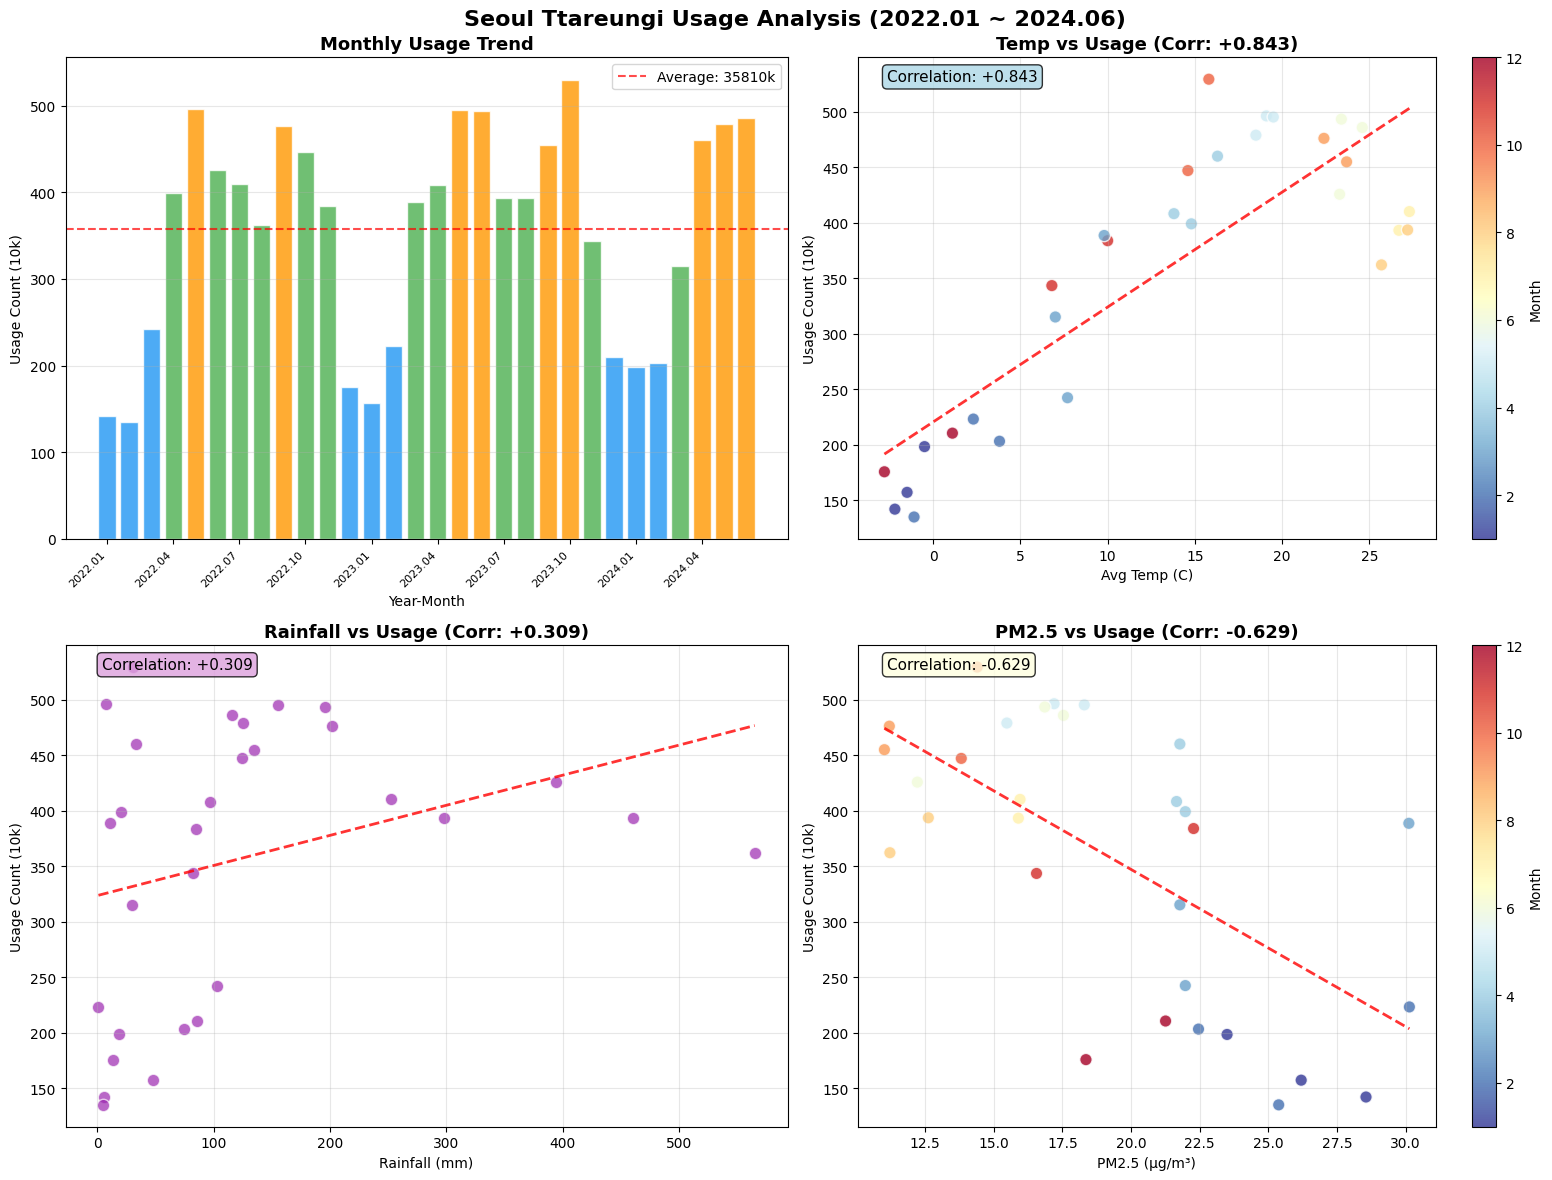

In [ ]:
x_labels = df['연월'].apply(lambda x: x[:4]+'.'+x[4:])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seoul Ttareungi Usage Analysis (2022.01 ~ 2024.06)',
             fontsize=16, fontweight='bold')

# (1) 월별 이용건수 추이
ax1 = axes[0, 0]
colors = ['#2196F3' if y < 3000000 else '#4CAF50' if y < 4500000 else '#FF9800'
          for y in df['이용건수']]
ax1.bar(range(len(df)), df['이용건수']/10000, color=colors, alpha=0.8, edgecolor='white')
ax1.set_title('Monthly Usage Trend', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Usage Count (10k)')
ax1.set_xticks(range(0, len(df), 3))
ax1.set_xticklabels(x_labels[::3], rotation=45, ha='right', fontsize=8)
ax1.axhline(y=df['이용건수'].mean()/10000, color='red', linestyle='--',
            alpha=0.7, label=f'Average: {df["이용건수"].mean()/10000:.0f}10k')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# (2) 기온 vs 이용건수
ax2 = axes[0, 1]
scatter = ax2.scatter(df['평균기온'], df['이용건수']/10000,
                      c=df['월'], cmap='RdYlBu_r', s=80, alpha=0.8, edgecolors='white')
z = np.polyfit(df['평균기온'], df['이용건수']/10000, 1)
p = np.poly1d(z)
x_line = np.linspace(df['평균기온'].min(), df['평균기온'].max(), 100)
ax2.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2)
ax2.set_title(f'Temp vs Usage (Corr: {corr_temp:+.3f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Avg Temp (C)')
ax2.set_ylabel('Usage Count (10k)')
plt.colorbar(scatter, ax=ax2, label='Month')
ax2.grid(alpha=0.3)
ax2.text(0.05, 0.95, f'Correlation: {corr_temp:+.3f}', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontsize=11)

# (3) 강수량 vs 이용건수
ax3 = axes[1, 0]
ax3.scatter(df['강수량'], df['이용건수']/10000, c='#9C27B0', s=80, alpha=0.7, edgecolors='white')
z2 = np.polyfit(df['강수량'], df['이용건수']/10000, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['강수량'].min(), df['강수량'].max(), 100)
ax3.plot(x_line2, p2(x_line2), 'r--', alpha=0.8, linewidth=2)
ax3.set_title(f'Rainfall vs Usage (Corr: {corr_rain:+.3f})', fontsize=13, fontweight='bold')
ax3.set_xlabel('Rainfall (mm)')
ax3.set_ylabel('Usage Count (10k)')
ax3.grid(alpha=0.3)
ax3.text(0.05, 0.95, f'Correlation: {corr_rain:+.3f}', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8), fontsize=11)

# (4) PM2.5 vs 이용건수 (NEW — 실제 vs 예측 자리에 PM2.5 산점도)
ax4 = axes[1, 1]
scatter4 = ax4.scatter(df['PM2.5'], df['이용건수']/10000,
                       c=df['월'], cmap='RdYlBu_r', s=80, alpha=0.8, edgecolors='white')
z3 = np.polyfit(df['PM2.5'], df['이용건수']/10000, 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df['PM2.5'].min(), df['PM2.5'].max(), 100)
ax4.plot(x_line3, p3(x_line3), 'r--', alpha=0.8, linewidth=2)
ax4.set_title(f'PM2.5 vs Usage (Corr: {corr_pm25:+.3f})', fontsize=13, fontweight='bold')
ax4.set_xlabel('PM2.5 (μg/m³)')
ax4.set_ylabel('Usage Count (10k)')
plt.colorbar(scatter4, ax=ax4, label='Month')
ax4.grid(alpha=0.3)
ax4.text(0.05, 0.95, f'Correlation: {corr_pm25:+.3f}', transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=11)

plt.tight_layout()
plt.savefig('ttareungi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge

# 시간순 정렬 (시계열 CV의 전제)
df_sorted = df.sort_values('연월').reset_index(drop=True)
y = df_sorted['이용건수']

# === 시계열 CV: 과거로 미래를 예측 ===
# n_splits=5: 학습셋이 점점 커지면서 그 다음 구간을 테스트
tscv = TimeSeriesSplit(n_splits=5)

# 비교할 모델 × 변수 조합
configs = {
    'RF + 기존(기온+강수량+월)':       (RandomForestRegressor(n_estimators=100, random_state=42), ['평균기온','강수량','월']),
    'RF + PM2.5 추가':                (RandomForestRegressor(n_estimators=100, random_state=42), ['평균기온','강수량','월','PM2.5']),
    'Linear + 기존':                  (LinearRegression(),                                         ['평균기온','강수량','월']),
    'Linear + PM2.5 추가':            (LinearRegression(),                                         ['평균기온','강수량','월','PM2.5']),
    'Ridge + PM2.5 추가':             (Ridge(alpha=1.0),                                           ['평균기온','강수량','월','PM2.5']),
}

results = []
for name, (model, features) in configs.items():
    X = df_sorted[features]
    
    cv_r2 = cross_val_score(model, X, y, cv=tscv, scoring='r2').mean()
    cv_mae = -cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error').mean()
    
    # 학습 R² (과적합 진단용)
    model.fit(X, y)
    r2_train = r2_score(y, model.predict(X))
    
    results.append({
        '모델': name,
        '변수수': len(features),
        'R²(학습)': f"{r2_train:.3f}",
        'R²(시계열CV)': f"{cv_r2:+.3f}",
        'MAE(CV)': f"{cv_mae:,.0f}",
        '과적합 갭': f"{r2_train - cv_r2:.3f}",
    })

results_df = pd.DataFrame(results)
print("=" * 80)
print("시계열 CV 모델 비교 (TimeSeriesSplit, n_splits=5)")
print("=" * 80)
print(results_df.to_string(index=False))
print()
print("해석:")
print("  - R²(학습): 학습 데이터를 얼마나 잘 맞추는지 (높을수록 외움)")
print("  - R²(시계열CV): 미래를 얼마나 잘 예측하는지 (실제 성능)")
print("  - 과적합 갭: 학습-CV 차이. 클수록 과적합.")

시계열 CV 모델 비교 (TimeSeriesSplit, n_splits=5)
               모델  변수수 R²(학습) R²(시계열CV) MAE(CV)  과적합 갭
RF + 기존(기온+강수량+월)    3  0.987    +0.418 405,160  0.569
    RF + PM2.5 추가    4  0.987    +0.356 421,255  0.630
      Linear + 기존    3  0.878    -2.103 611,054  2.981
Linear + PM2.5 추가    4  0.878    -9.600 903,530 10.478
 Ridge + PM2.5 추가    4  0.878    -0.719 620,722  1.597

해석:
  - R²(학습): 학습 데이터를 얼마나 잘 맞추는지 (높을수록 외움)
  - R²(시계열CV): 미래를 얼마나 잘 예측하는지 (실제 성능)
  - 과적합 갭: 학습-CV 차이. 클수록 과적합.


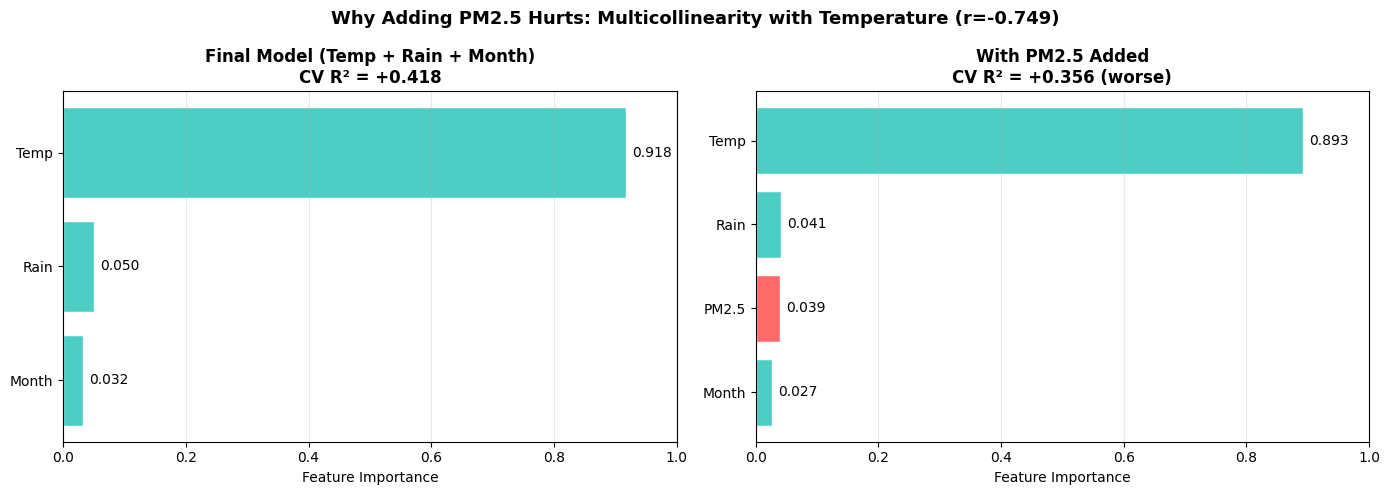

In [40]:
# 한글 → 영어 라벨 매핑
label_map = {
    '평균기온': 'Temp',
    '강수량': 'Rain',
    '월': 'Month',
    'PM2.5': 'PM2.5'
}

# Feature Importance 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 기존 모델
imp1 = pd.Series(final_model.feature_importances_, index=final_features).sort_values()
imp1.index = [label_map[x] for x in imp1.index]
axes[0].barh(imp1.index, imp1.values, color='#4ECDC4', edgecolor='white')
axes[0].set_title('Final Model (Temp + Rain + Month)\nCV R² = +0.418', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Importance')
for i, v in enumerate(imp1.values):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, 1)

# (우) PM2.5 추가 모델
imp2 = pd.Series(model_with_pm.feature_importances_, index=['평균기온','강수량','월','PM2.5']).sort_values()
colors = ['#FF6B6B' if idx == 'PM2.5' else '#4ECDC4' for idx in imp2.index]
imp2.index = [label_map[x] for x in imp2.index]
axes[1].barh(imp2.index, imp2.values, color=colors, edgecolor='white')
axes[1].set_title('With PM2.5 Added\nCV R² = +0.356 (worse)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Importance')
for i, v in enumerate(imp2.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, 1)

plt.suptitle('Why Adding PM2.5 Hurts: Multicollinearity with Temperature (r=-0.749)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()